##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os

from google.colab import drive
drive.mount('/content/drive')

# ====== SET YOUR DATASET PATH HERE ======
# Example if the folder is directly inside MyDrive:
DATA_DIR = "/content/drive/MyDrive/UCF11"


CHOSEN_CLASSES = ["basketball", "biking", "diving"]

# ====== Sanity checks ======
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"Dataset folder was not found at:\n{DATA_DIR}\n\n"
        "Check the exact folder name and its location in Google Drive."
    )

print("Dataset folder ready:", DATA_DIR)

top_items = os.listdir(DATA_DIR)
print("Top-level items:", top_items[:20])

# Check chosen classes
missing_classes = [cls for cls in CHOSEN_CLASSES if not os.path.exists(os.path.join(DATA_DIR, cls))]
if missing_classes:
    raise FileNotFoundError(
        f"These class folders were not found inside DATA_DIR: {missing_classes}\n"
        f"Available folders: {top_items[:20]}"
    )

print("All chosen class folders found:", CHOSEN_CLASSES)

Mounted at /content/drive
Dataset folder ready: /content/drive/MyDrive/UCF11
Top-level items: ['readme.txt', 'horse_riding', 'basketball', 'biking', 'soccer_juggling', 'diving', 'golf_swing']
All chosen class folders found: ['basketball', 'biking', 'diving']


In [2]:
# Verify the class folders available in the dataset
import os

# The extracted folder may be named differently — auto-detect
for entry in os.listdir("."):
    if os.path.isdir(entry) and "UCF" in entry:
        DATA_DIR = entry
        break

classes_available = sorted(os.listdir(DATA_DIR))
print(f"Dataset root : {DATA_DIR}")
print(f"Classes found ({len(classes_available)}):")
for c in classes_available:
    print(" ", c)

Dataset root : /content/drive/MyDrive/UCF11
Classes found (7):
  basketball
  biking
  diving
  golf_swing
  horse_riding
  readme.txt
  soccer_juggling


In [3]:
import os
import glob

# ====== Google Drive dataset path ======
DATA_DIR = "/content/drive/MyDrive/UCF11"

# ====== Choose only these 3 classes ======
CHOSEN_CLASSES = ["basketball", "biking", "diving"]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}

# Common video extensions in UCF11 / similar datasets
VIDEO_EXTENSIONS = {".avi", ".mpg", ".mpeg", ".mp4"}

print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", os.path.exists(DATA_DIR))

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"DATA_DIR was not found:\n{DATA_DIR}\n"
        "Check your Google Drive path."
    )

print("\nTop-level items inside DATA_DIR:")
print(os.listdir(DATA_DIR)[:30])

video_paths, labels = [], []

for cls in CHOSEN_CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    print(f"\nChecking class folder: {cls_dir}")

    if not os.path.exists(cls_dir):
        print(f"  ❌ Folder not found for class '{cls}'")
        continue

    # Search recursively for video files
    all_files = glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)
    vids = [
        f for f in all_files
        if os.path.isfile(f) and os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS
    ]

    print(f"  ✅ {cls}: {len(vids)} videos")

    if len(vids) > 0:
        print("  Sample video:", vids[0])

    video_paths.extend(vids)
    labels.extend([CLASS_TO_IDX[cls]] * len(vids))

print("\nSelected classes:", CHOSEN_CLASSES)
print("Label mapping   :", CLASS_TO_IDX)
print(f"Total videos: {len(video_paths)}")

if len(video_paths) == 0:
    print("\n⚠️ No videos found.")
    print("Most likely reasons:")
    print("1) DATA_DIR is not the correct folder")
    print("2) Class folders are nested incorrectly")
    print("3) Video files use a different extension")
    print("4) The dataset was uploaded with the wrong structure")

DATA_DIR: /content/drive/MyDrive/UCF11
DATA_DIR exists: True

Top-level items inside DATA_DIR:
['readme.txt', 'horse_riding', 'basketball', 'biking', 'soccer_juggling', 'diving', 'golf_swing']

Checking class folder: /content/drive/MyDrive/UCF11/basketball
  ✅ basketball: 141 videos
  Sample video: /content/drive/MyDrive/UCF11/basketball/v_shooting_23/v_shooting_23_01.avi

Checking class folder: /content/drive/MyDrive/UCF11/biking
  ✅ biking: 145 videos
  Sample video: /content/drive/MyDrive/UCF11/biking/v_biking_25/v_biking_25_01.avi

Checking class folder: /content/drive/MyDrive/UCF11/diving
  ✅ diving: 156 videos
  Sample video: /content/drive/MyDrive/UCF11/diving/v_diving_24/v_diving_24_02.avi

Selected classes: ['basketball', 'biking', 'diving']
Label mapping   : {'basketball': 0, 'biking': 1, 'diving': 2}
Total videos: 442


Preprocessing videos — please wait ...
X shape : (442, 16, 224, 224, 3)
y shape : (442,)
Class distribution: {'basketball': 141, 'biking': 145, 'diving': 156}


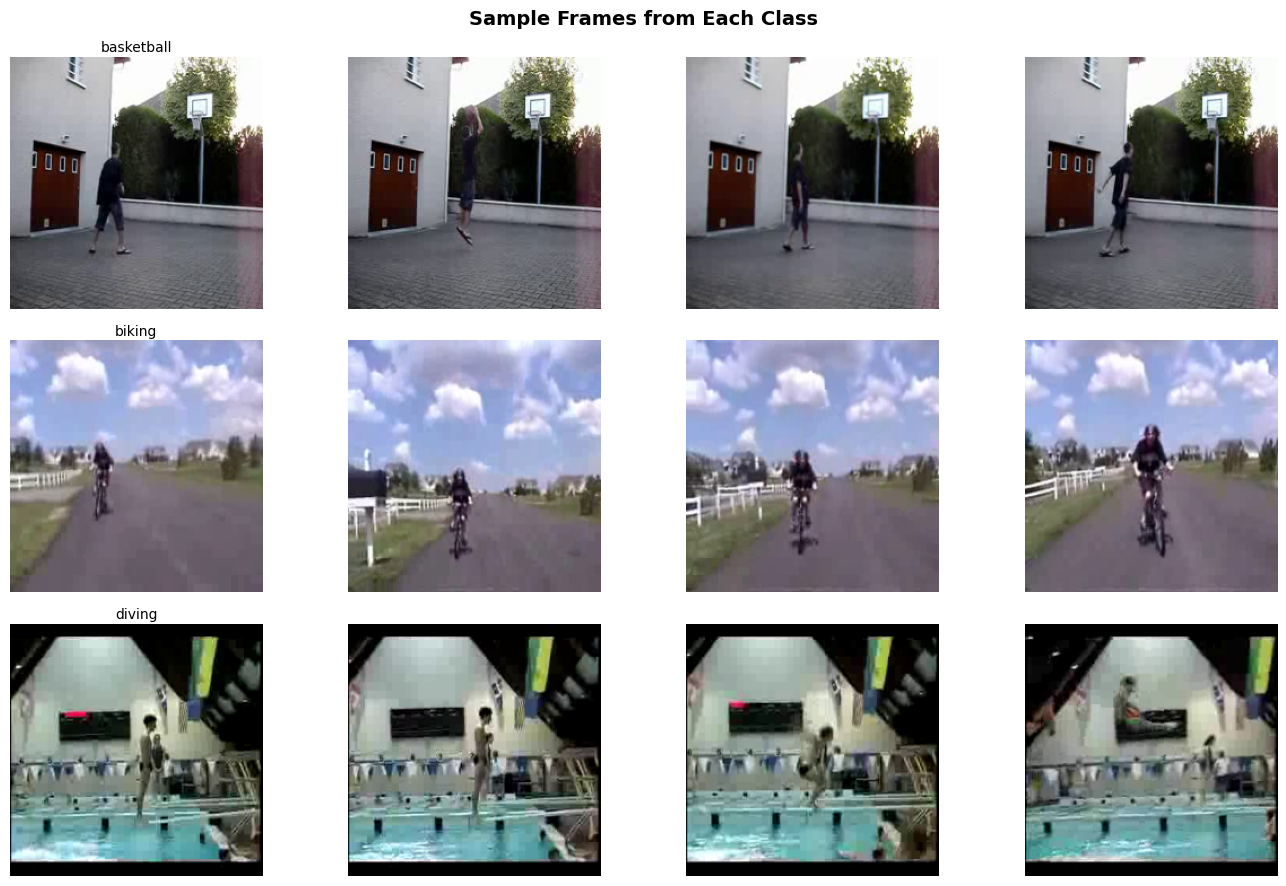

In [4]:
# ── Quick visual sanity check ─────────────────────────────────────────
import matplotlib.pyplot as plt
import os
import glob
import cv2
import numpy as np   

# ── Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE     = 224
SEQUENCE_LEN = 16

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls, i in CLASS_TO_IDX.items()} }")
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Sample Frames from Each Class", fontsize=14, fontweight="bold")

for row, cls_idx in enumerate(range(len(CHOSEN_CLASSES))):
    sample_vid_idx = np.where(y == cls_idx)[0][0]
    frames = X[sample_vid_idx]  # 16 frames
    for col, frame_idx in enumerate([0, 4, 8, 12]):
        axes[row, col].imshow(frames[frame_idx])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(IDX_TO_CLASS[cls_idx], fontsize=10, pad=4)

plt.tight_layout()
plt.show()

In [5]:
import cv2
import numpy as np

# ── Hyper-parameters ──────────────────────────────────────────────────
IMG_SIZE       = 224      # MobileNetV2 expects 224×224
SEQUENCE_LEN   = 16       # frames sampled per video
# ──────────────────────────────────────────────────────────────────────

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    """Uniformly sample n_frames from a video and return as numpy array."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0   # normalise to [0,1]


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)   # shape: (N, 16, 224, 224, 3)
y = np.array(y)   # shape: (N,)

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls,i in CLASS_TO_IDX.items()} }")

Preprocessing videos — please wait ...

X shape : (442, 16, 224, 224, 3)
y shape : (442,)
Class distribution: {'basketball': 141, 'biking': 145, 'diving': 156}


In [6]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# One-hot encode labels
NUM_CLASSES = len(CHOSEN_CLASSES)
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing  samples  : {X_test.shape[0]}")
print(f"Input tensor shape: {X_train.shape}  →  (samples, frames, H, W, C)")

Training samples  : 353
Testing  samples  : 89
Input tensor shape: (353, 16, 224, 224, 3)  →  (samples, frames, H, W, C)


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_lstm_model(sequence_len, img_size, num_classes):
    # ── CNN Backbone (MobileNetV2, ImageNet weights, frozen) ──────────
    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base_cnn.trainable = False   # freeze for initial training

    # ── Full Model ────────────────────────────────────────────────────
    inp = layers.Input(shape=(sequence_len, img_size, img_size, 3))

    # Apply MobileNetV2 to every frame
    x = layers.TimeDistributed(base_cnn)(inp)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)  # (batch, seq, 1280)

    # Temporal modelling
    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dropout(0.4)(x)

    # Classifier head
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out, name="CNN_LSTM_ActionRecognizer")
    return model, base_cnn


model, base_cnn = build_cnn_lstm_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CNN_LSTM_ActionRecognizer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,843 (11.40 MB)

 Trainable params: 729,859 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

tf.keras.backend.clear_session()
import gc; gc.collect()

IMG_SIZE     = 112   
SEQUENCE_LEN = 8     

# ── Step 3: Re-preprocess with smaller sizes ──────────────────────────
print("Re-preprocessing with reduced dimensions ...")

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    import cv2, numpy as np
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0

import numpy as np
X, y = [], []
for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)
print(f"✅ X shape: {X.shape}  y shape: {y.shape}")

# ── Step 4: Re-split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
NUM_CLASSES  = len(CHOSEN_CLASSES)
y_train_cat  = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat   = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

# ── Step 5: Rebuild lighter model for 112x112 input ───────────────────
from tensorflow.keras import layers, models

def build_model(seq_len, img_size, num_classes):
    # MobileNetV2 still works at 112x112 (minimum is 96x96)
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inp = layers.Input(shape=(seq_len, img_size, img_size, 3))
    x   = layers.TimeDistributed(base)(inp)
    x   = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x   = layers.LSTM(64, return_sequences=False)(x)   # 64 instead of 128
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(64, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out), base

model, base_cnn = build_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("✅ Model rebuilt")

# ── Step 6: Train with mixed precision + smaller batch ────────────────
tf.keras.mixed_precision.set_global_policy("mixed_float16") 

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor="val_accuracy",
                    save_best_only=True, verbose=1)
]

print("=" * 55)
print(" Phase 1: Training head only (backbone frozen)")
print("=" * 55)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=15,
    batch_size=2,        
    callbacks=callbacks
)

Re-preprocessing with reduced dimensions ...
✅ X shape: (442, 8, 112, 112, 3)  y shape: (442,)
Train: 353  Test: 89


/tmp/ipykernel_1514/260718077.py:60: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


✅ Model rebuilt
 Phase 1: Training head only (backbone frozen)
Epoch 1/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6338 - loss: 0.8601
Epoch 1: val_accuracy improved from None to 0.97753, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - accuracy: 0.7309 - loss: 0.6772 - val_accuracy: 0.9775 - val_loss: 0.2065 - learning_rate: 0.0010
Epoch 2/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9079 - loss: 0.2712
Epoch 2: val_accuracy did not improve from 0.97753
177/177 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9150 - loss: 0.2479 - val_accuracy: 0.9663 - val_loss: 0.0927 - learning_rate: 0.0010
Epoch 3/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9662 - loss: 0.1361
Epoch 3: val_accuracy did not improve from 0.97753
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9688 - loss: 0.1078 - val_accuracy: 0.9326 - val_loss: 0.1387 - learning_rate: 0.0010
Epoch 4/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9666 - loss: 0.1248
Epoch 4: val_accuracy did not improve from 0.97753
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9745 - loss: 0.0842 - val_accuracy: 0.9775 - val_los

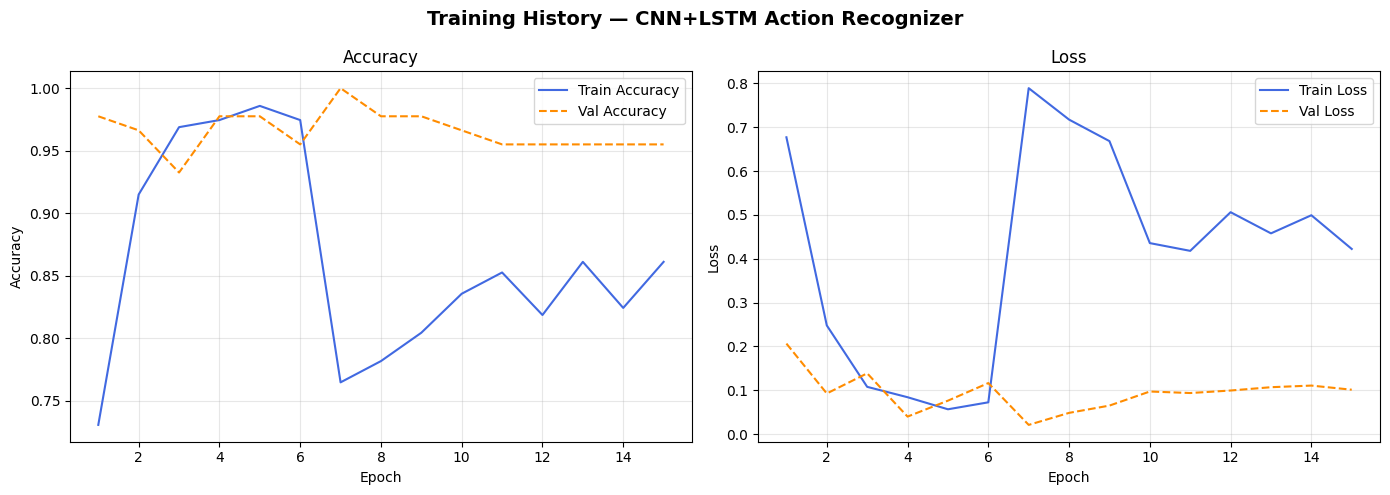

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Combine both training phases
def merge_hist(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc     = merge_hist(history, history_ft, "accuracy")
val_acc = merge_hist(history, history_ft, "val_accuracy")
loss    = merge_hist(history, history_ft, "loss")
val_los = merge_hist(history, history_ft, "val_loss")
ep      = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — CNN+LSTM Action Recognizer", fontsize=14, fontweight="bold")

ax1.plot(ep, acc,     label="Train Accuracy",   color="royalblue")
ax1.plot(ep, val_acc, label="Val Accuracy",     color="darkorange", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,    label="Train Loss",       color="royalblue")
ax2.plot(ep, val_los, label="Val Loss",         color="darkorange", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Test Accuracy : 97.75%
Test Loss     : 0.2065

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step 
              precision    recall  f1-score   support

  basketball       0.96      0.96      0.96        28
      biking       1.00      0.97      0.98        29
      diving       0.97      1.00      0.98        32

    accuracy                           0.98        89
   macro avg       0.98      0.98      0.98        89
weighted avg       0.98      0.98      0.98        89



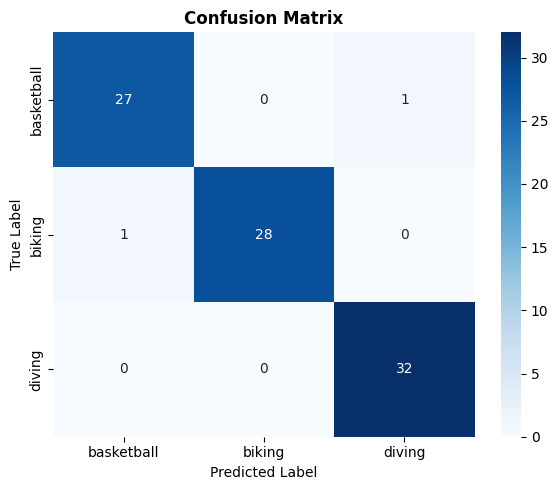

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n{'='*40}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"{'='*40}\n")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CHOSEN_CLASSES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CHOSEN_CLASSES, yticklabels=CHOSEN_CLASSES)
plt.title("Confusion Matrix", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
student_name = "Raghad Aljiban"

save_path = f"/content/drive/MyDrive/{student_name}_ucf11_model.h5"

model.save(save_path)

print(f"✅ Model saved as: {save_path}")

✅ Model saved as: /content/drive/MyDrive/Raghad Aljiban_ucf11_model.h5


In [26]:
import json

student_name = "Raghad Aljiban"

meta = {
    "student": student_name,
    "classes": CHOSEN_CLASSES,
    "label_map": CLASS_TO_IDX,
    "sequence_len": SEQUENCE_LEN,
    "img_size": IMG_SIZE,
    "test_accuracy": round(float(test_acc), 4)
}

meta_path = f"/content/drive/MyDrive/{student_name}_metadata.json"

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"✅ Metadata created: {meta_path}")

✅ Metadata created: /content/drive/MyDrive/Raghad Aljiban_metadata.json
